DATASET_CREATION


In [ ]:
!pip install tensorflow

In [ ]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd

In [ ]:
import tensorflow as tf
tf.keras.utils.get_file(
    'esc-50.zip',
    'https://github.com/karoldvl/ESC-50/archive/master.zip',
    cache_dir='./',
    cache_subdir='datasets',
    extract=True
)

645695005/645695005 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


'./datasets/esc-50_extracted'

In [ ]:
def audio_combination(ydrone,srdrone,ynoise,srnoise,ratio=0.5):  #drone: (yd, srd),   noise: [ (yn1, srn1), (yn2, srn2).....]
    nor_ydrone = librosa.util.normalize(ydrone)
    nor_ynoise = np.sum(ynoise,axis=0)
    nor_ynoise = librosa.util.normalize(nor_ynoise)
    mixed_audio = ratio * nor_ydrone + (1 - ratio) * nor_ynoise
    mixed_audio = librosa.util.normalize(mixed_audio)
    if srdrone == np.average(srnoise):
      return mixed_audio,srdrone


In [ ]:
csv_file_path = '/content/datasets/esc-50_extracted/ESC-50-master/meta/esc50.csv'
df = pd.read_csv(csv_file_path)
drone_fname = []
for i in range(15):
  drone_fname.append(f'/content/drone/d{i+1}_1.WAV')
  drone_fname.append(f'/content/drone/d{i+1}_5.WAV')
df.head(5)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [ ]:
categories = list(df['category'].unique())
remove = [
    'toilet_flush',
    'brushing_teeth',
    'snoring',
    'drinking_sipping',
    'keyboard_typing',
    'door_wood_creaks',
    'can_opening',
    'crying_baby',
    'mouse_click',
    'clapping'
]
for i in remove:
  categories.remove(i)
print(len(categories))

40


In [ ]:
import random
df_gen = pd.DataFrame(columns=['noise1234','noise1_loc','noise2_loc','noise3_loc','noise4_loc','drone_loc','mixed','ratio'])
for i in range(5000):
  entry = []
  samp_cat = random.sample(categories,4)           # 4 noises, 1 drone, RATIO: 0.4*drone + 0.6*noise
  entry.append(samp_cat)
  principath = r'/content/datasets/esc-50_extracted/ESC-50-master/audio/'
  ynoise = []
  srnoise = []
  for j in range(len(samp_cat)):
    path = random.sample(list(df[df['category']==samp_cat[j]]['filename'].unique()),1)
    entry.append(path[0])
    path = principath + path[0]
    y,sr = librosa.load(path)
    ynoise.append(y)
    srnoise.append(sr)
  ynoise,srnoise = np.array(ynoise),np.array(srnoise)
  drn_path = random.sample(drone_fname,1)
  entry.append(drn_path[0])
  yd,srd = librosa.load(drn_path[0],duration=5)
  y,sr = audio_combination(ynoise = ynoise, srnoise=srnoise, ydrone=yd, srdrone=srd,ratio=0.3)
  from scipy.io.wavfile import write as write_wav
  file_name = f'/content/generated_data/mixed_{i:05d}.wav'
  write_wav(file_name,sr,y)
  entry.append(file_name)
  entry.append(0.4)
  df_gen.loc[len(df_gen)] = entry
df_gen.head()

,noise1234,noise1_loc,noise2_loc,noise3_loc,noise4_loc,drone_loc,mixed,ratio
0,"[insects, vacuum_cleaner, siren, thunderstorm]",1-46938-B-7.wav,5-212059-A-36.wav,2-43802-A-42.wav,2-104105-A-19.wav,/content/drone/d4_5.WAV,/content/generated_data/mixed_00000.wav,0.4
1,"[frog, engine, train, crow]",2-32515-B-4.wav,1-22882-A-44.wav,2-122067-B-45.wav,5-213836-C-9.wav,/content/drone/d5_1.WAV,/content/generated_data/mixed_00001.wav,0.4
2,"[engine, hen, laughing, siren]",4-201988-A-44.wav,1-18074-A-6.wav,3-118487-A-26.wav,4-90014-A-42.wav,/content/drone/d11_1.WAV,/content/generated_data/mixed_00002.wav,0.4
3,"[crackling_fire, sneezing, laughing, hand_saw]",5-193473-B-12.wav,4-156843-A-21.wav,1-1791-A-26.wav,3-97909-A-49.wav,/content/drone/d13_1.WAV,/content/generated_data/mixed_00003.wav,0.4
4,"[engine, cat, church_bells, crow]",4-186935-A-44.wav,2-82274-B-5.wav,1-21421-A-46.wav,3-121348-A-9.wav,/content/drone/d4_1.WAV,/content/generated_data/mixed_00004.wav,0.4


In [ ]:
df_gen

,noise1234,noise1_loc,noise2_loc,noise3_loc,noise4_loc,drone_loc,mixed,ratio
0,"[insects, vacuum_cleaner, siren, thunderstorm]",1-46938-B-7.wav,5-212059-A-36.wav,2-43802-A-42.wav,2-104105-A-19.wav,/content/drone/d4_5.WAV,/content/generated_data/mixed_00000.wav,0.4
1,"[frog, engine, train, crow]",2-32515-B-4.wav,1-22882-A-44.wav,2-122067-B-45.wav,5-213836-C-9.wav,/content/drone/d5_1.WAV,/content/generated_data/mixed_00001.wav,0.4
2,"[engine, hen, laughing, siren]",4-201988-A-44.wav,1-18074-A-6.wav,3-118487-A-26.wav,4-90014-A-42.wav,/content/drone/d11_1.WAV,/content/generated_data/mixed_00002.wav,0.4
3,"[crackling_fire, sneezing, laughing, hand_saw]",5-193473-B-12.wav,4-156843-A-21.wav,1-1791-A-26.wav,3-97909-A-49.wav,/content/drone/d13_1.WAV,/content/generated_data/mixed_00003.wav,0.4
4,"[engine, cat, church_bells, crow]",4-186935-A-44.wav,2-82274-B-5.wav,1-21421-A-46.wav,3-121348-A-9.wav,/content/drone/d4_1.WAV,/content/generated_data/mixed_00004.wav,0.4
...,...,...,...,...,...,...,...,...
4995,"[wind, cow, clock_tick, church_bells]",4-163609-A-16.wav,2-117795-A-3.wav,3-170383-A-38.wav,5-179294-A-46.wav,/content/drone/d10_5.WAV,/content/generated_data/mixed_04995.wav,0.4
4996,"[hen, car_horn, footsteps, helicopter]",2-157488-A-6.wav,2-128465-A-43.wav,3-103597-A-25.wav,4-175000-B-40.wav,/content/drone/d8_5.WAV,/content/generated_data/mixed_04996.wav,0.4
4997,"[dog, fireworks, chainsaw, thunderstorm]",2-118072-A-0.wav,3-119120-D-48.wav,1-64398-B-41.wav,1-23222-B-19.wav,/content/drone/d3_5.WAV,/content/generated_data/mixed_04997.wav,0.4
4998,"[clock_alarm, engine, crow, siren]",1-96890-A-37.wav,1-18527-A-44.wav,2-109231-A-9.wav,5-117122-A-42.wav,/content/drone/d2_5.WAV,/content/generated_data/mixed_04998.wav,0.4


['clock_alarm', 'engine', 'chainsaw', 'fireworks']


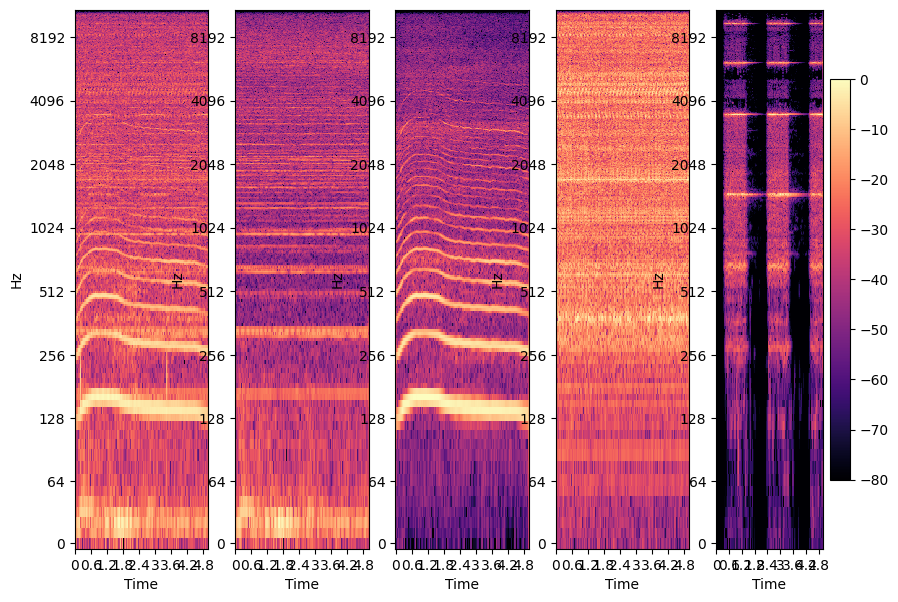

In [ ]:
### FOR VIEWING
i = 4532
fig,ax = plt.subplots(ncols = 5, figsize = (10,7))
fn1 = '/content/datasets/esc-50_extracted/ESC-50-master/audio/' + df_gen['noise1_loc'][i]
fn2 = '/content/datasets/esc-50_extracted/ESC-50-master/audio/' + df_gen['noise2_loc'][i]
fn3 = '/content/datasets/esc-50_extracted/ESC-50-master/audio/' + df_gen['noise3_loc'][i]
dfn = df_gen['drone_loc'][i]
mixed = df_gen['mixed'][i]
print(df_gen['noise1234'][i])
yn1,sn1 = librosa.load(fn1)
yn2,sn2 = librosa.load(fn2)
yn3,sn3 = librosa.load(fn3)
ym1,sm1 = librosa.load(mixed)
yd,sd = librosa.load(dfn,duration=5)
img = librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(yn1)),ref=np.max),y_axis='log', x_axis='time', ax=ax[4])
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(yn2)),ref=np.max),y_axis='log', x_axis='time', ax=ax[3])
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(yn3)),ref=np.max),y_axis='log', x_axis='time', ax=ax[2])
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(yd)),ref=np.max),y_axis='log', x_axis='time', ax=ax[1])
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(ym1)),ref=np.max),y_axis='log', x_axis='time', ax=ax[0])
fig.colorbar(img)
ipd.Audio(data=ym1,rate=sm1)

MODEL


In [ ]:
from tensorflow.keras import layers, Model
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def get_spec(path, sr=16000, n_fft=1024, hop=128):
    y, _ = librosa.load(path, duration=5)
    S = librosa.stft(librosa.util.normalize(y), n_fft=n_fft, hop_length=hop)
    mag = np.abs(S)
    log_mag = np.log1p(mag)
    log_mag = (log_mag - log_mag.mean()) / (log_mag.std() + 1e-8)
    return log_mag, mag

class DataGen(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=8):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size

    def __len__(self):
        return len(self.df) // self.batch_size

    def __getitem__(self, idx):
        batch = self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size]

        X, Y = [], []

        for _, row in batch.iterrows():
            x_norm, mix_mag = get_spec(row["mixed"])
            _, drone_mag = get_spec(row["drone_loc"])

            # Align time frames (to avoid shape mismatch)
            min_frames = min(mix_mag.shape[1], drone_mag.shape[1])
            x_norm = x_norm[:, :min_frames]
            mix_mag = mix_mag[:, :min_frames]
            drone_mag = drone_mag[:, :min_frames]

            # Compute true mask (S_drone / mix_mag)
            mask = drone_mag / (mix_mag + 1e-8)
            mask = np.sqrt(np.clip(mask, 0, 1))       #cha

            # Append normalized input
            X.append(x_norm)

            # Pack mask and mix_mag as channels in y_true for the loss
            y_true = np.stack([mask, mix_mag], axis=-1)  # shape: (freq_bins, time_frames, 2)
            Y.append(y_true)

        X = np.array(X)[..., np.newaxis]
        Y = np.array(Y)

        return X, Y


In [ ]:
df_gen_train = df_gen.head(4001)
train_gen = DataGen(df_gen_train, batch_size=10)
def masked_reconstruction_loss(y_true, y_pred, epsilon=1e-8):
    mask_true = y_true[..., 0]
    mix_mag = y_true[..., 1]

    S_true = mask_true * mix_mag
    S_pred = y_pred[..., 0] * mix_mag

    return tf.reduce_mean(tf.square(S_pred - S_true))

In [ ]:
def build_model(freq_bins):
    inp = layers.Input(shape=(freq_bins, None, 1))
    x = layers.Conv2D(64, 4, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Permute((2,1,3))(x)
    x = layers.Reshape((-1, x.shape[2]*x.shape[3]))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dense(freq_bins, activation='sigmoid')(x)
    x = layers.Permute((2,1))(x)
    out = layers.Reshape((freq_bins, -1, 1))(x)
    return Model(inp, out)

In [ ]:
F = get_spec(df_gen_train.iloc[0]["mixed"])[0].shape[0]
model = build_model(F)
model.compile(optimizer='adam', loss=masked_reconstruction_loss)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 513, None, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 513, None, 64)  │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 256, None, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, None, 128) │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, None, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_8 (Permute)             │ (None, None, 128, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_8 (Reshape)             │ (None, None, 16384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, None, 128)      │     8,421,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, None, 513)      │        66,177 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_9 (Permute)             │ (None, 513, None)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 513, None, 1)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,563,009 (32.67 MB)

 Trainable params: 8,563,009 (32.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.load_weights('/content/80we.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.fit(train_gen, epochs=8)

Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 242s 588ms/step - loss: 0.6692
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 236s 588ms/step - loss: 0.3614
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 587ms/step - loss: 0.3071
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 587ms/step - loss: 0.2800
Epoch 5/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 587ms/step - loss: 0.2576
Epoch 6/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 586ms/step - loss: 0.2422
Epoch 7/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 585ms/step - loss: 0.2345
Epoch 8/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 586ms/step - loss: 0.2248


In [ ]:
model.save_weights('/content/better_weight.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
['car_horn', 'sneezing', 'frog', 'washing_machine'] 4181


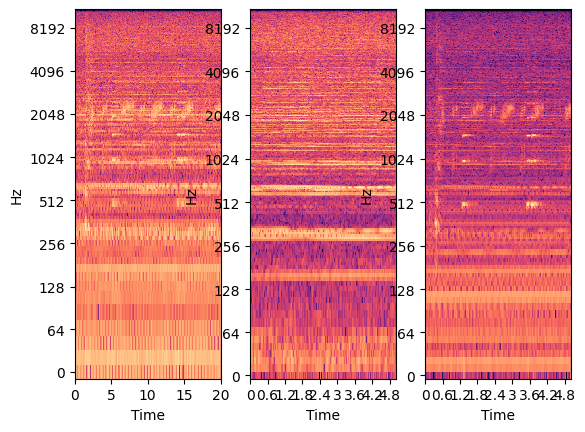

In [ ]:
i =random.randint(4001,4900)                    #4598,4583 impres
log_mag,_ = get_spec(df_gen['mixed'][i])
inp = log_mag[np.newaxis, ..., np.newaxis]
pred_mask = model.predict(inp)
y,sr = librosa.load(df_gen['mixed'][i],duration=5)
S = np.abs(librosa.stft(y, n_fft=1024, hop_length=128))
S_hat = pred_mask[0, ..., 0] * S
fig,ax = plt.subplots(ncols=3)
librosa.display.specshow(librosa.amplitude_to_db(S_hat,ref=np.max),y_axis='log', x_axis='time',ax=ax[0])
yd,srd = librosa.load(df_gen['drone_loc'][i],duration=5)
ym,srm = librosa.load(df_gen['mixed'][i],duration=5)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(yd)),ref=np.max),y_axis='log', x_axis='time',ax=ax[1])
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(ym)),ref=np.max),y_axis='log', x_axis='time',ax=ax[2])
phase = np.angle(librosa.stft(ym, n_fft=1024, hop_length=128))
S_hat = S_hat * np.exp(1j * phase)
y_recon = librosa.istft(S_hat, hop_length=128)
print(df_gen['noise1234'][i],i)
ipd.Audio(data=y_recon,rate=srm)

In [ ]:
ipd.Audio(data=ym,rate=srm)